# Load Libraries

In [1]:
library(tidyverse)
library(knitr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Load Datasets

In [2]:
#====samstats====
sn_wide <- read.table(
  "../local_results/03_post_align_QC/samstats/SN.txt",
  header = TRUE, sep = "\t", row.names = 1,
  check.names = FALSE
)

# pivot to long format for plotting
sn <- sn_wide %>%
  rownames_to_column("metric") %>%
  pivot_longer(-metric, names_to = "sample", values_to = "value") %>%
  mutate(value = as.numeric(value))

kable(sn_wide)

#====Coverage====

cov <- read.table(
  "../local_results/03_post_align_QC/coverage/coverage_0.1kb.bed.gz",
  header=FALSE)
colnames(cov) <- c("chromosome", "start", "end", "mean", "median", "count")

cov[, 4] <- as.numeric(cov[,4])
cov[, 5] <- as.numeric(cov[,5])

kable(head(cov))


cov1kb <- read.table(
  "../local_results/03_post_align_QC/coverage/coverage_1kb.bed.gz",
  header=FALSE)
colnames(cov1kb) <- c("chromosome", "start", "end", "mean", "median", "count")

cov1kb[, 4] <- as.numeric(cov1kb[,4])
cov1kb[, 5] <- as.numeric(cov1kb[,5])

kable(head(cov1kb))



|                                         |  SRR25084096|  SRR25084097|  SRR25084098|  SRR25084099|  SRR25084100|  SRR25084101|  SRR25084102|  SRR25084103|
|:----------------------------------------|------------:|------------:|------------:|------------:|------------:|------------:|------------:|------------:|
|raw total sequences:                     | 3.333944e+06| 1.986344e+06| 1.284020e+06| 1.285682e+06| 1.285086e+06| 3.039460e+06| 1.597786e+06| 1.732284e+06|
|filtered sequences:                      | 0.000000e+00| 0.000000e+00| 0.000000e+00| 0.000000e+00| 0.000000e+00| 0.000000e+00| 0.000000e+00| 0.000000e+00|
|sequences:                               | 3.333944e+06| 1.986344e+06| 1.284020e+06| 1.285682e+06| 1.285086e+06| 3.039460e+06| 1.597786e+06| 1.732284e+06|
|is sorted:                               | 1.000000e+00| 1.000000e+00| 1.000000e+00| 1.000000e+00| 1.000000e+00| 1.000000e+00| 1.000000e+00| 1.000000e+00|
|1st fragments:                           | 1.666972e+06| 9.93



|chromosome    | start| end|   mean| median| count|
|:-------------|-----:|---:|------:|------:|-----:|
|NZ_CP009273.1 |     0| 100| 359.06|  369.0|   100|
|NZ_CP009273.1 |   100| 200| 446.13|  446.0|   100|
|NZ_CP009273.1 |   200| 300| 528.69|  532.0|   100|
|NZ_CP009273.1 |   300| 400| 491.15|  499.0|   100|
|NZ_CP009273.1 |   400| 500| 464.03|  467.0|   100|
|NZ_CP009273.1 |   500| 600| 532.72|  539.5|   100|



|chromosome    | start|  end|    mean| median| count|
|:-------------|-----:|----:|-------:|------:|-----:|
|NZ_CP009273.1 |     0| 1000| 525.301|  530.0|  1000|
|NZ_CP009273.1 |  1000| 2000| 610.960|  618.0|  1000|
|NZ_CP009273.1 |  2000| 3000| 548.174|  546.5|  1000|
|NZ_CP009273.1 |  3000| 4000| 463.855|  463.0|  1000|
|NZ_CP009273.1 |  4000| 5000| 509.675|  517.0|  1000|
|NZ_CP009273.1 |  5000| 6000| 568.416|  592.0|  1000|

# QC Plots - samstats

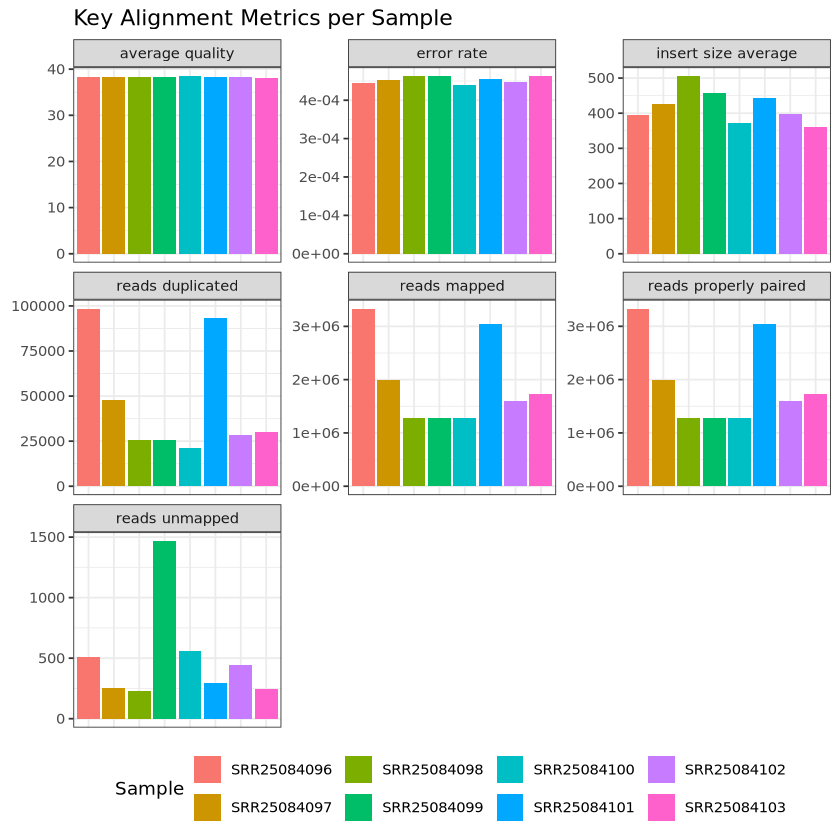

In [3]:
# Key metrics to assess alignment quality
key_metrics <- c(
  "reads mapped:",
  "reads unmapped:",
  "reads duplicated:",
  "reads properly paired:",
  "error rate:",
  "average quality:",
  "insert size average:"
)

sn_key <- sn %>% filter(metric %in% key_metrics) %>%
  mutate(metric = str_remove(metric, ":$"))

ggplot(sn_key, aes(x = sample, y = value, fill = sample)) +
  geom_col() +
  facet_wrap(~metric, scales = "free_y") +
  theme_bw() +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
        legend.position = "bottom") +
  labs(x = NULL, y = NULL, fill = "Sample",
       title = "Key Alignment Metrics per Sample")

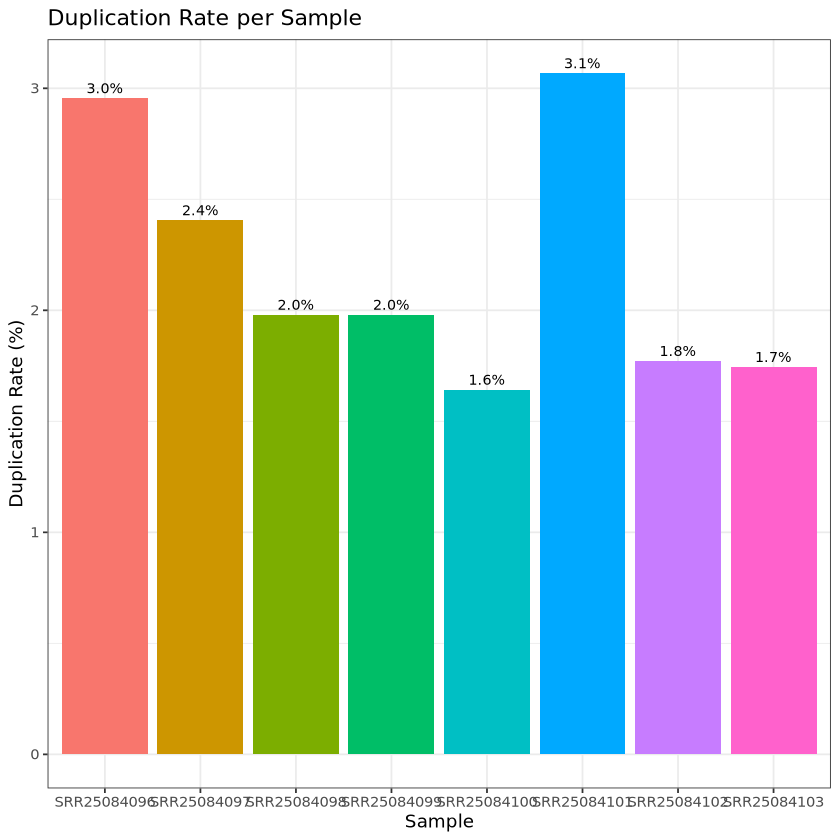

In [4]:
# Duplication rate (%)
sn %>%
  filter(metric %in% c("reads mapped:", "reads duplicated:")) %>%
  mutate(metric = str_remove(metric, ":$")) %>%
  pivot_wider(names_from = metric, values_from = value) %>%
  mutate(dup_rate = `reads duplicated` / `reads mapped` * 100) %>%
  ggplot(aes(x = sample, y = dup_rate, fill = sample)) +
  geom_col() +
  geom_text(aes(label = sprintf("%.1f%%", dup_rate)), vjust = -0.5, size = 3) +
  theme_bw() +
  theme(legend.position = "none") +
  labs(x = "Sample", y = "Duplication Rate (%)",
       title = "Duplication Rate per Sample")

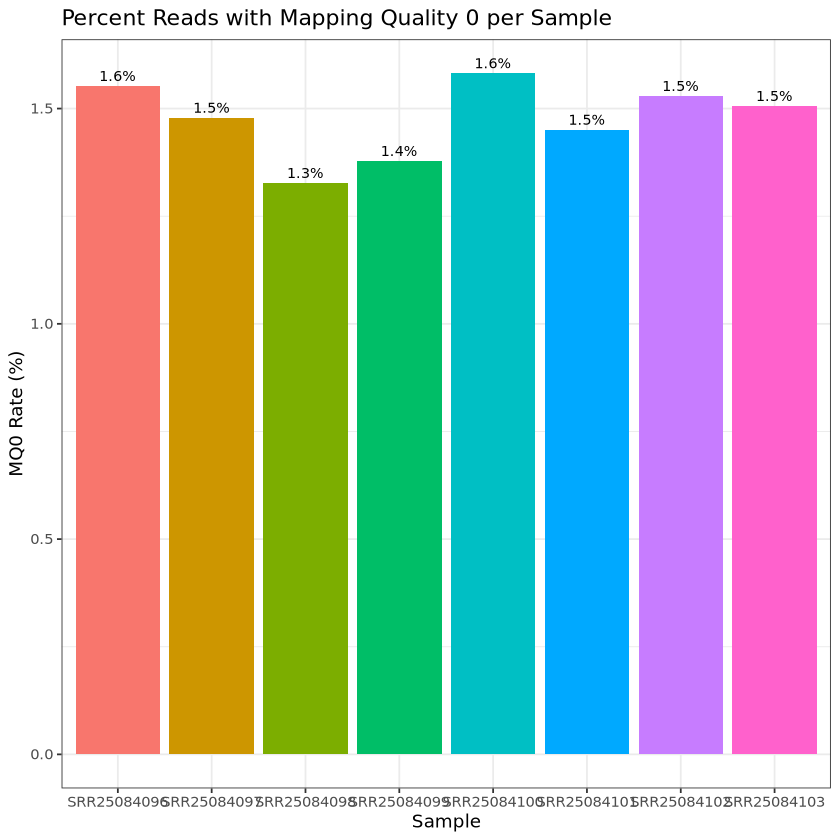

In [5]:
# MQ0 rate (%) - reads with mapping quality 0 indicate ambiguous alignments
sn %>%
  filter(metric %in% c("reads mapped:", "reads MQ0:")) %>%
  mutate(metric = str_remove(metric, ":$")) %>%
  pivot_wider(names_from = metric, values_from = value) %>%
  mutate(mq0_rate = `reads MQ0` / `reads mapped` * 100) %>%
  ggplot(aes(x = sample, y = mq0_rate, fill = sample)) +
  geom_col() +
  geom_text(aes(label = sprintf("%.1f%%", mq0_rate)), vjust = -0.5, size = 3) +
  theme_bw() +
  theme(legend.position = "none") +
  labs(x = "Sample", y = "MQ0 Rate (%)",
       title = "Percent Reads with Mapping Quality 0 per Sample")

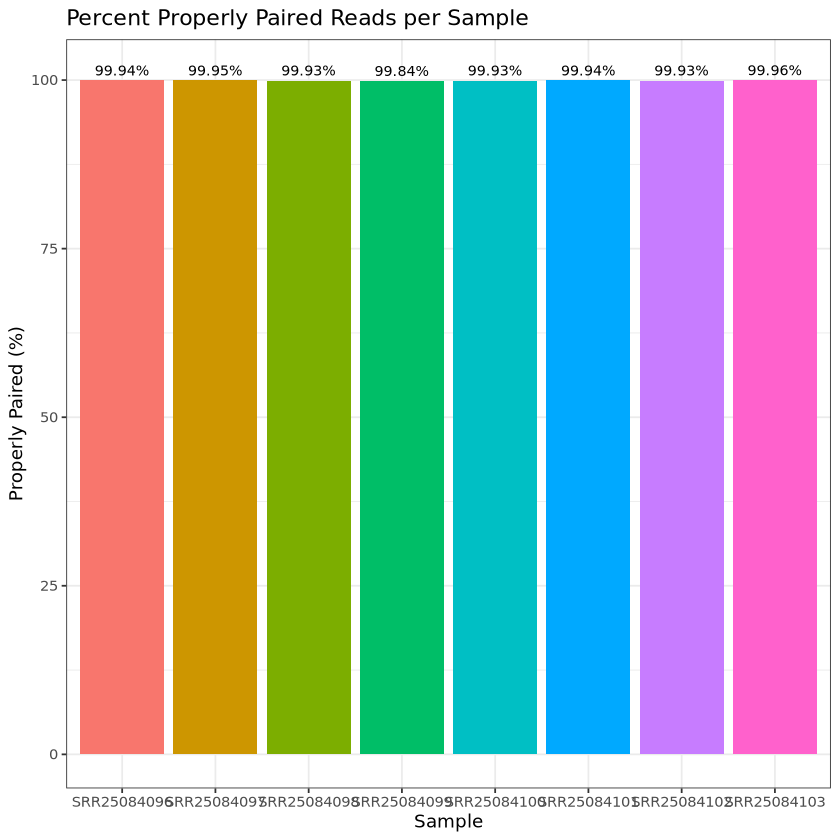

In [6]:
# Percent properly paired reads
sn %>%
  filter(metric %in% c("reads paired:", "reads properly paired:")) %>%
  mutate(metric = str_remove(metric, ":$")) %>%
  pivot_wider(names_from = metric, values_from = value) %>%
  mutate(pct_proper = `reads properly paired` / `reads paired` * 100) %>%
  ggplot(aes(x = sample, y = pct_proper, fill = sample)) +
  geom_col() +
  geom_text(aes(label = sprintf("%.2f%%", pct_proper)), vjust = -0.5, size = 3) +
  scale_y_continuous(limits = c(0, 101)) +
  theme_bw() +
  theme(legend.position = "none") +
  labs(x = "Sample", y = "Properly Paired (%)",
       title = "Percent Properly Paired Reads per Sample")

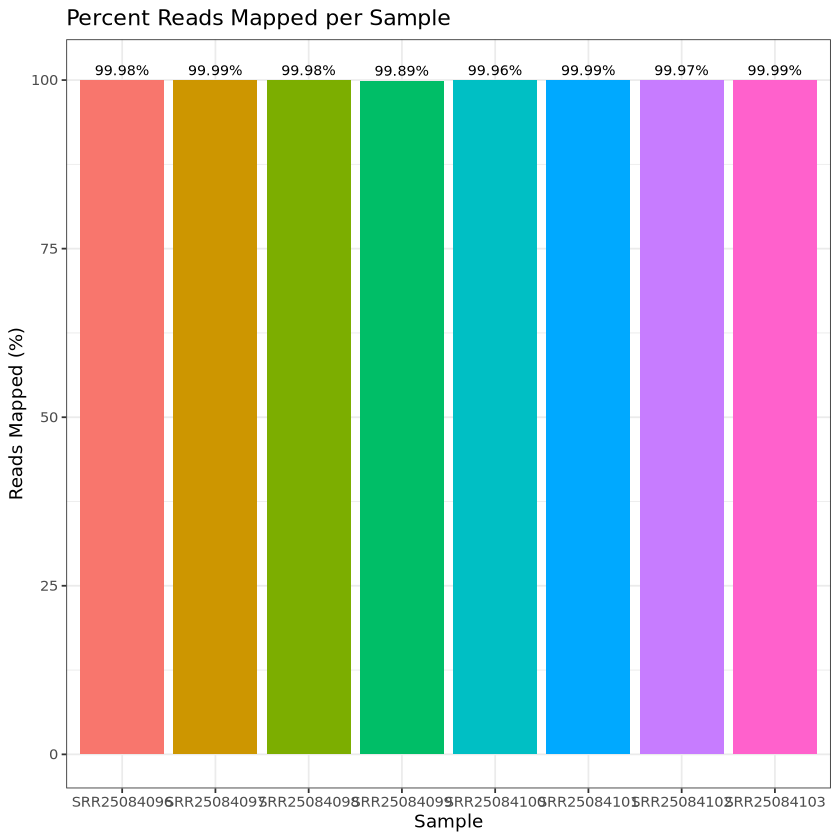

In [7]:
# Percent reads mapped per sample
sn %>%
  filter(metric %in% c("sequences:", "reads mapped:")) %>%
  mutate(metric = str_remove(metric, ":$")) %>%
  pivot_wider(names_from = metric, values_from = value) %>%
  mutate(pct_mapped = `reads mapped` / sequences * 100) %>%
  ggplot(aes(x = sample, y = pct_mapped, fill = sample)) +
  geom_col() +
  geom_text(aes(label = sprintf("%.2f%%", pct_mapped)), vjust = -0.5, size = 3) +
  scale_y_continuous(limits = c(0, 101)) +
  theme_bw() +
  theme(legend.position = "none") +
  labs(x = "Sample", y = "Reads Mapped (%)",
       title = "Percent Reads Mapped per Sample")

# QC Plots - Coverage - 0.1KB window

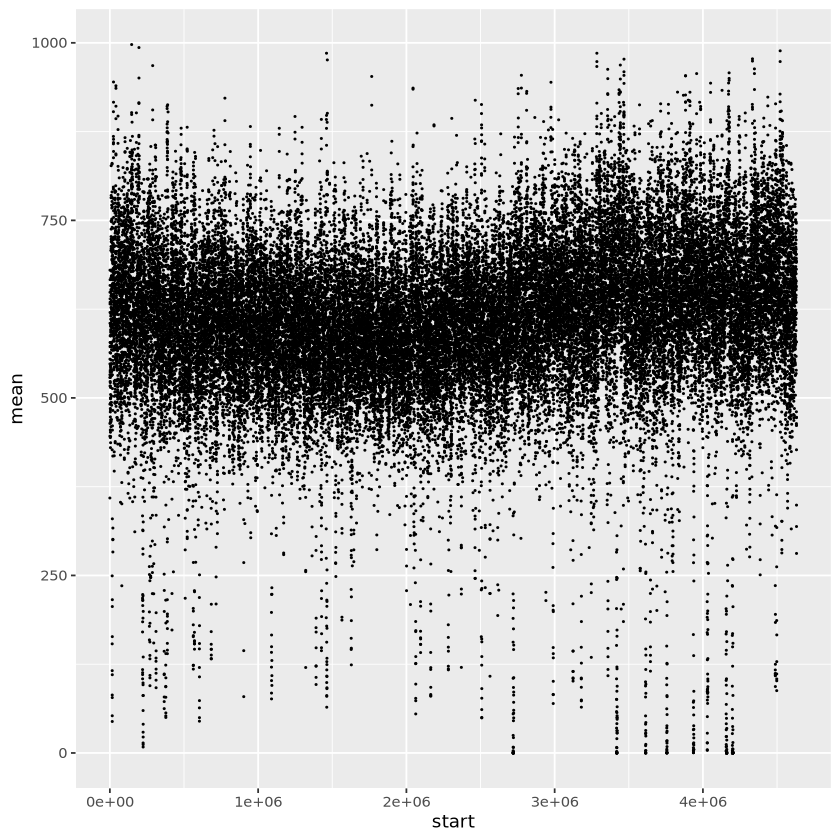

In [8]:
ggplot(cov, aes(x=start, y=mean)) + 
  geom_point(size=0.2)

While coverage seemes to be high throughout the plot,I was curious why the coverage doesnt appear 'flat' and appeared to be biased thwards one particular area. My suspicion was that the cells in growth phase have a 'forking chromosome' meaning the portions of the genome closer to the origin of replication are likely to have more fragments. I centered the plot on the approximate origin of replication in E coli and made the x axis defined by relative distance to the origin and it does appear to be the case.

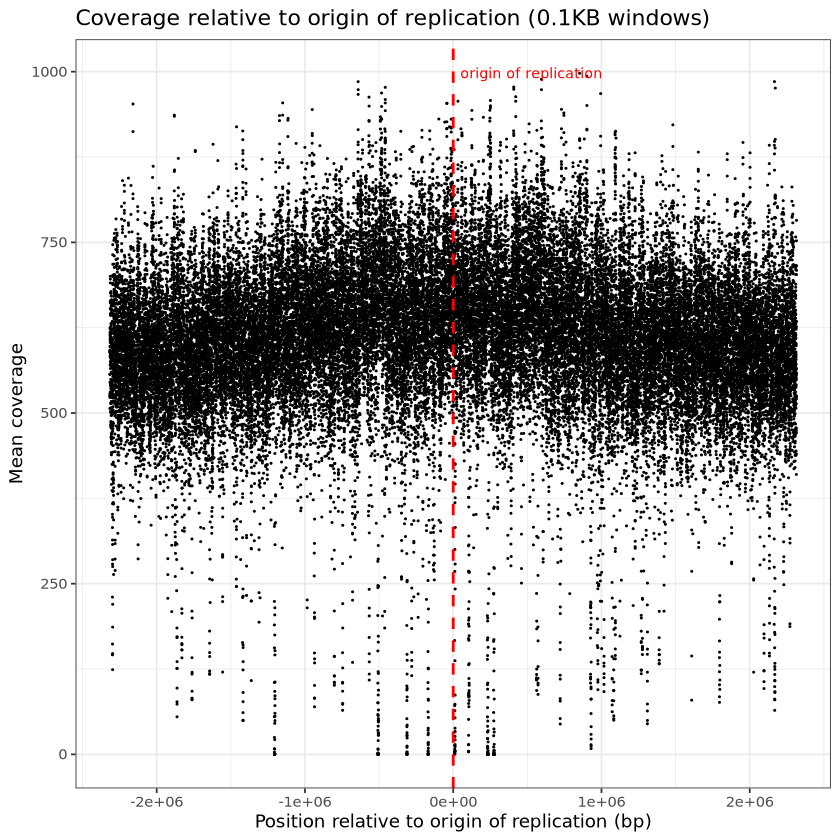

In [9]:
ori <- 3925744
genome_size <- max(cov$end, na.rm = TRUE)

cov_ori <- cov %>%
  mutate(
    d = start - ori,
    pos_from_ori = case_when(
      d >  genome_size / 2 ~ d - genome_size,
      d < -genome_size / 2 ~ d + genome_size,
      TRUE ~ d
    )
  )
max_dist <- max(abs(cov_ori$pos_from_ori), na.rm = TRUE)

ggplot(cov_ori, aes(x = pos_from_ori, y = mean)) +
  geom_point(size = 0.2) +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed", linewidth = 0.8) +
  annotate("text", x = 0, y = max(cov_ori$mean, na.rm = TRUE),
           label = "origin of replication", color = "red", hjust = -0.05, size = 3) +
  scale_x_continuous(limits = c(-max_dist, max_dist)) +
  theme_bw() +
  labs(x = "Position relative to origin of replication (bp)", y = "Mean coverage",
       title = "Coverage relative to origin of replication (0.1KB windows)")



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


[1] 832

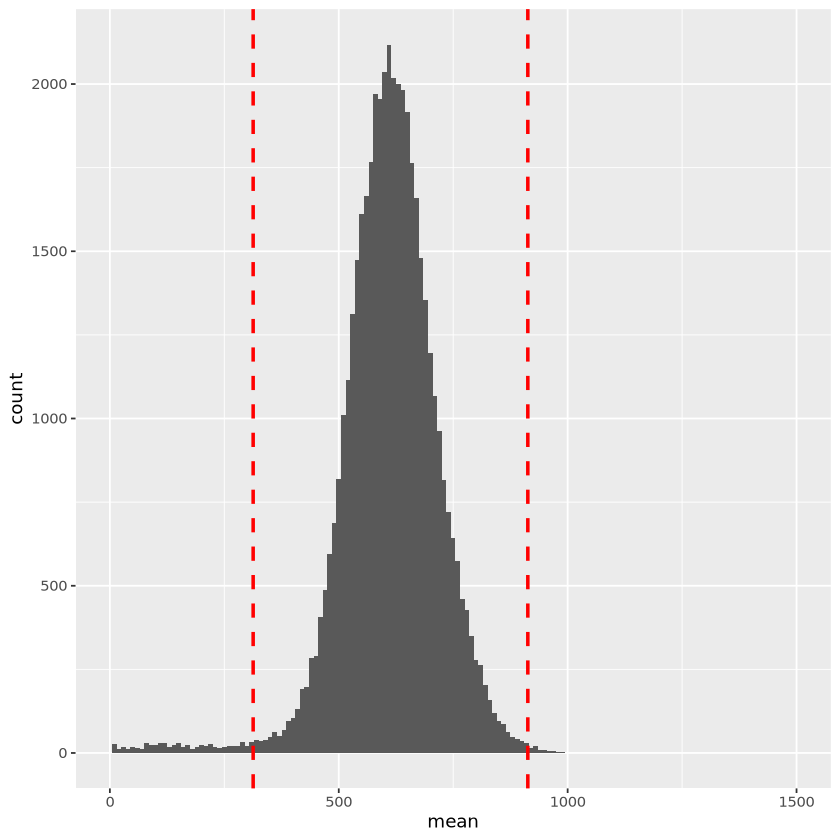

In [10]:
median =median(cov$median)

half_range <- 300

lower_bound <- median - half_range
upper_bound <- median + half_range

ggplot(cov, aes(x=mean)) + 
  geom_histogram(binwidth=10) +
  xlim(0,1500) + 
  geom_vline(xintercept=c(lower_bound, upper_bound), color="red", linetype="dashed", size=1)

  lost_windows <- sum(cov$mean < lower_bound | cov$mean > upper_bound)

  lost_windows

# QC Plots - Coverage - 1KB window

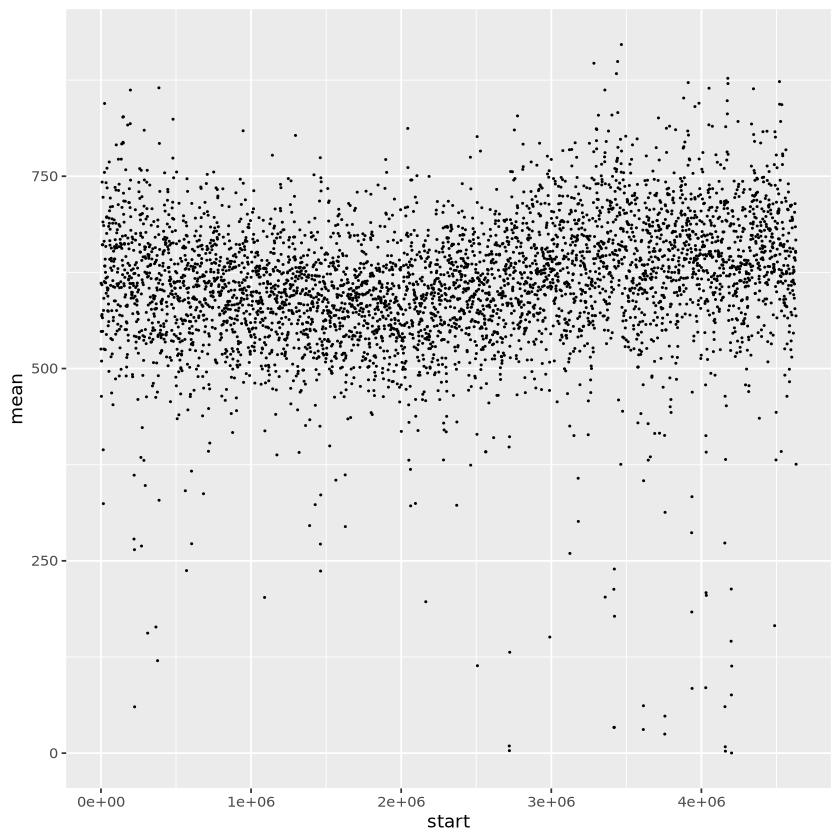

In [11]:
ggplot(cov1kb, aes(x=start, y=mean)) + 
  geom_point(size=0.2)

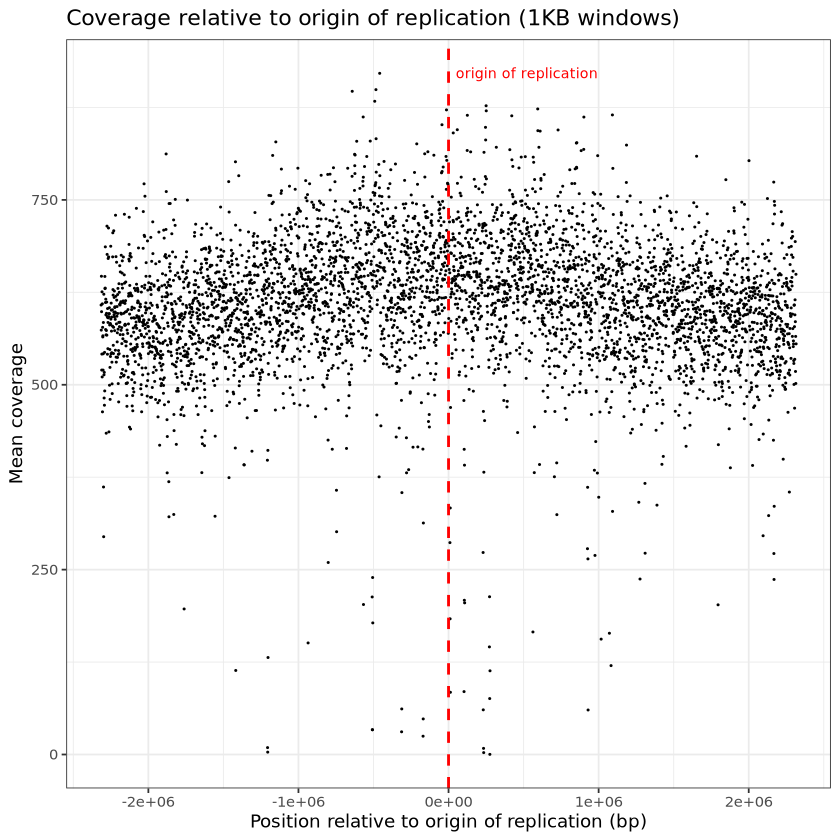

In [12]:
ori <- 3925744
genome_size1kb <- max(cov1kb$end, na.rm = TRUE)

cov1kb_ori <- cov1kb %>%
  mutate(
    d = start - ori,
    pos_from_ori = case_when(
      d >  genome_size1kb / 2 ~ d - genome_size1kb,
      d < -genome_size1kb / 2 ~ d + genome_size1kb,
      TRUE ~ d
    )
  )
max_dist1kb <- max(abs(cov1kb_ori$pos_from_ori), na.rm = TRUE)

ggplot(cov1kb_ori, aes(x = pos_from_ori, y = mean)) +
  geom_point(size = 0.2) +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed", linewidth = 0.8) +
  annotate("text", x = 0, y = max(cov1kb_ori$mean, na.rm = TRUE),
           label = "origin of replication", color = "red", hjust = -0.05, size = 3) +
  scale_x_continuous(limits = c(-max_dist1kb, max_dist1kb)) +
  theme_bw() +
  labs(x = "Position relative to origin of replication (bp)", y = "Mean coverage",
       title = "Coverage relative to origin of replication (1KB windows)")

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


[1] 50

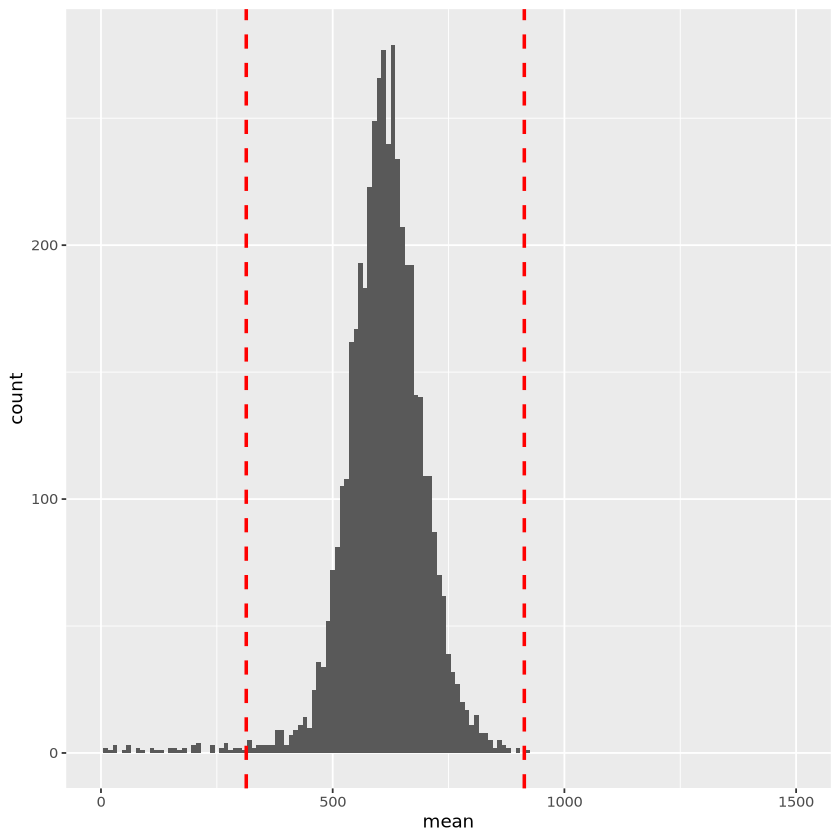

In [13]:
median1kb <- median(cov1kb$median)

half_range <- 300

lower_bound <- median1kb - half_range
upper_bound <- median1kb + half_range

ggplot(cov1kb, aes(x=mean)) + 
  geom_histogram(binwidth=10) +
  xlim(0,1500) + 
  geom_vline(xintercept=c(lower_bound, upper_bound), color="red", linetype="dashed", size=1)

lost_windows <- sum(cov1kb$mean < lower_bound | cov1kb$mean > upper_bound)

lost_windows